Name : Sakshi Kapil Badave
PRN : 202401110019

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
texts = [
    "I love this movie",
    "This movie is amazing",
    "The movie was excellent",
    "I really enjoyed the movie",
    "Fantastic and wonderful movie",
    "The acting was great",
    "I hated this movie",
    "This movie is terrible",
    "The movie was boring",
    "I did not enjoy the movie",
    "Worst movie ever",
    "The acting was bad",
    "I love this product",
    "This product is excellent",
    "Amazing quality and service",
    "I am very happy with this product",
    "I hate this product",
    "This product is awful",
    "Very poor quality",
    "I am disappointed with this product"
]

In [3]:
labels = [
    1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0,
    1, 1, 1, 1,
    0, 0, 0, 0
]

In [5]:
labels = np.array(labels)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.25,
    random_state=42,
    stratify=labels
)

In [7]:
vocab_size = 5000

In [8]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [9]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [11]:
max_length = 10

In [12]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

In [13]:
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

In [14]:
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_length
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [15]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=20,
    batch_size=4,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step - accuracy: 0.5000 - loss: 0.6965 - val_accuracy: 0.3333 - val_loss: 0.6980
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5000 - loss: 0.6977 - val_accuracy: 0.3333 - val_loss: 0.7041
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5833 - loss: 0.6827 - val_accuracy: 0.3333 - val_loss: 0.7095
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5833 - loss: 0.6863 - val_accuracy: 0.3333 - val_loss: 0.7132
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5833 - loss: 0.6750 - val_accuracy: 0.3333 - val_loss: 0.7187
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5833 - loss: 0.6835 - val_accuracy: 0.3333 - val_loss: 0.7255
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5833 - loss: 0.6820 - val_accuracy: 0.3333 - val_loss: 0.7333
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5833 - loss: 0.6783 - val_accuracy: 0.3333 - val_loss: 0.7421

In [18]:
y_probability = model.predict(X_test_pad)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 776ms/step


In [19]:
y_pred = (y_probability >= 0.5).astype(int).flatten()

In [20]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

In [21]:
print("\nModel Performance")
print("-------------------------")
print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)


Model Performance
-------------------------
Accuracy  : 0.4
Precision : 0.4
Recall    : 1.0
F1 Score  : 0.5714285714285714


In [22]:
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"],
    zero_division=0
))


Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         3
    Positive       0.40      1.00      0.57         2

    accuracy                           0.40         5
   macro avg       0.20      0.50      0.29         5
weighted avg       0.16      0.40      0.23         5



In [23]:
cm = confusion_matrix(y_test, y_pred)

In [25]:
print("\nConfusion Matrix:")
print(cm)




Confusion Matrix:
[[0 3]
 [0 2]]


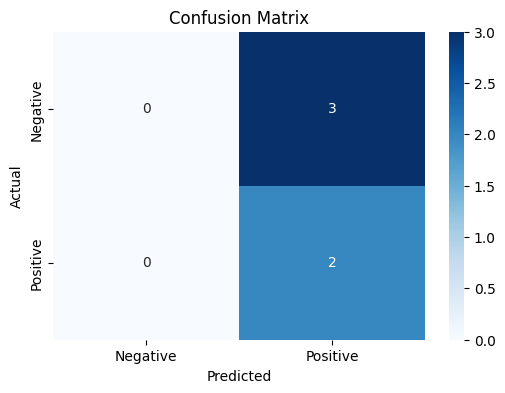

In [26]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

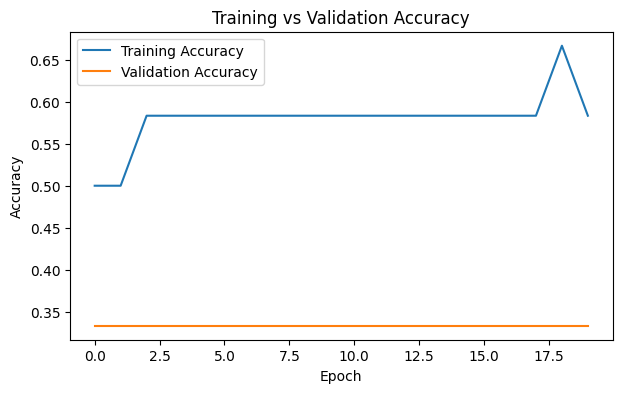

In [27]:
plt.figure(figsize=(7, 4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


In [28]:
new_texts = [
    "This movie was fantastic",
    "The movie was very boring",
    "I love this product",
    "This product is terrible"
]

In [29]:
new_sequences = tokenizer.texts_to_sequences(new_texts)

In [30]:
new_padded = pad_sequences(
    new_sequences,
    maxlen=max_length,
    padding='post'
)

In [31]:
predictions = model.predict(new_padded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


In [32]:
print("\nNew Text Predictions:")

for text, prediction in zip(new_texts, predictions):
    if prediction[0] >= 0.5:
        result = "Positive"
    else:
        result = "Negative"

    print(text, "->", result)


New Text Predictions:
This movie was fantastic -> Positive
The movie was very boring -> Positive
I love this product -> Positive
This product is terrible -> Negative
